In [3]:
from google.colab import files

uploaded = files.upload()

Saving Consumer_Complaints.xlsx to Consumer_Complaints (1).xlsx


In [4]:
import pandas as pd

In [5]:
df = pd.read_excel("Consumer_Complaints.xlsx")

In [6]:
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,NaN,Company has responded to the consumer and the ...,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the ...,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes


In [7]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows and Columns: (62516, 12)

Column Names:
['Complaint ID', 'Submitted via', 'Date submitted', 'Date received', 'State', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company response to consumer', 'Timely response?']

Data Types:
Complaint ID                             int64
Submitted via                           object
Date submitted                  datetime64[ns]
Date received                   datetime64[ns]
State                                   object
Product                                 object
Sub-product                             object
Issue                                   object
Sub-issue                               object
Company public response                 object
Company response to consumer            object
Timely response?                        object
dtype: object


## Initial Dataset Understanding

- The dataset contains approximately **62k customer complaints**.
- It includes complaint dates, product categories, issue categories, response details, and geographic information.
- Date columns will need conversion to datetime format for trend analysis.
- Product and Issue columns appear to be categorical fields suitable for segmentation analysis.
- The dataset is suitable for analysing customer experience, complaint trends, operational performance, and complaint prioritisation.italicised text

In [8]:
# Check missing values
missing_values = df.isnull().sum()

# Missing values as a percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into one table
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
})

# Show only columns with missing values
missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
Sub-issue,10858,17.37
Company public response,2175,3.48
Timely response?,1494,2.39
Sub-product,7,0.01


In [9]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Count duplicate Complaint IDs
print("Duplicate Complaint IDs:", df["Complaint ID"].duplicated().sum())

Duplicate Complaint IDs: 0


No duplicate complaint records were found. The dataset is suitable for further analysis.

In [11]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62509 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     51658 non-null  object        
 9   Company public response       60341 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [12]:
# See how many unique values each column has
df.nunique()

,0
Complaint ID,62516
Submitted via,7
Date submitted,2308
Date received,2305
State,51
Product,9
Sub-product,46
Issue,76
Sub-issue,158
Company public response,6


In [13]:
# Display all unique products
df["Product"].unique()

array(['Mortgage', 'Money transfer, virtual currency, or money service',
       'Credit reporting, credit repair services, or other personal consumer reports',
       'Credit card or prepaid card', 'Checking or savings account',
       'Vehicle loan or lease', 'Debt collection',
       'Payday loan, title loan, or personal loan', 'Student loan'],
      dtype=object)

In [14]:
# Count complaints for each product
df["Product"].value_counts()

,count
Product,
Checking or savings account,24814
Credit card or prepaid card,16197
"Credit reporting, credit repair services, or other personal consumer reports",7710
Mortgage,6601
"Money transfer, virtual currency, or money service",3453
Debt collection,2736
Vehicle loan or lease,633
"Payday loan, title loan, or personal loan",333
Student loan,39


In [15]:
# Count complaints by submission channel
df["Submitted via"].value_counts()

,count
Submitted via,
Web,45423
Referral,10766
Phone,4684
Postal mail,1318
Fax,233
Web Referral,90
Email,2


The majority of complaints are submitted through digital channels like web, indicating customers prefer online methods for reporting issues.

In [16]:
# Top 10 complaint issues
df["Issue"].value_counts().head(10)

,count
Issue,
Managing an account,15109
Incorrect information on your report,4931
Problem with a purchase shown on your statement,4415
Closing an account,2953
Trouble during payment process,2827
Opening an account,2725
Problem with a lender or other company charging your account,2493
Fraud or scam,1987
Struggling to pay mortgage,1904


The majority of complaints are concentrated around a large number of recurring issues, indicating clear areas where operational and customer service improvements can have the greatest impact.

In [17]:
# Create Response Time in Days
df["Response Time (Days)"] = (
    df["Date received"] - df["Date submitted"]
).dt.days

In [18]:
df[["Date submitted", "Date received", "Response Time (Days)"]].head()

,Date submitted,Date received,Response Time (Days)
0,2021-10-24,2021-10-27,3
1,2020-04-24,2020-04-24,0
2,2022-07-27,2022-07-27,0
3,2023-07-10,2023-07-11,1
4,2022-07-27,2022-07-28,1


Feature Engineering: Created a new variable called Response Time (Days) to measure the time taken by the company to receive and begin processing customer complaints. This feature will be used to evaluate operational efficiency and support service performance analysis.

In [19]:
# Create a new column for Complaint Year
df["Complaint Year"] = df["Date submitted"].dt.year

In [20]:
df[["Date submitted", "Complaint Year"]].head()

,Date submitted,Complaint Year
0,2021-10-24,2021
1,2020-04-24,2020
2,2022-07-27,2022
3,2023-07-10,2023
4,2022-07-27,2022


Feature Engineering: Extracted the complaint year from the submission date to enable year-over-year trend analysis and support strategic business reporting.

In [21]:
# Create a new column for Complaint Month
df["Complaint Month"] = df["Date submitted"].dt.month_name()

In [22]:
df[["Date submitted", "Complaint Month"]].head()

,Date submitted,Complaint Month
0,2021-10-24,October
1,2020-04-24,April
2,2022-07-27,July
3,2023-07-10,July
4,2022-07-27,July


Feature Engineering: Extracted the complaint month from the submission date to analyse monthly complaint trends and identify potential seasonal patterns in customer complaints.

In [23]:
# Create Complaint Quarter
df["Complaint Quarter"] = df["Date submitted"].dt.quarter

In [24]:
df[["Date submitted", "Complaint Quarter"]].head()

,Date submitted,Complaint Quarter
0,2021-10-24,4
1,2020-04-24,2
2,2022-07-27,3
3,2023-07-10,3
4,2022-07-27,3


In [25]:
# Count missing values
df.isnull().sum()

,0
Complaint ID,0
Submitted via,0
Date submitted,0
Date received,0
State,0
Product,0
Sub-product,7
Issue,0
Sub-issue,10858
Company public response,2175


In [26]:
# Fill missing values

df["Sub-product"] = df["Sub-product"].fillna("Not Specified")

df["Sub-issue"] = df["Sub-issue"].fillna("Not Specified")

df["Company public response"] = df["Company public response"].fillna("No Public Response")

In [27]:
df.isnull().sum()

,0
Complaint ID,0
Submitted via,0
Date submitted,0
Date received,0
State,0
Product,0
Sub-product,0
Issue,0
Sub-issue,0
Company public response,0


Missing values in Sub-product, Sub-issue, and Company Public Response were replaced with meaningful labels rather than removed, ensuring complaint records were preserved while improving data quality for reporting and dashboard development.

In [28]:
# Check the values in the Timely response? column
df["Timely response?"].value_counts(dropna=False)

,count
Timely response?,
Yes,58619
No,2403
NaN,1494


In [29]:
df["Timely response?"].value_counts()

,count
Timely response?,
Yes,58619
No,2403


In [30]:
df["Timely response?"].isnull().sum()

np.int64(1494)

In [31]:
# Checking data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62516 entries, 0 to 62515
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Complaint ID                  62516 non-null  int64         
 1   Submitted via                 62516 non-null  object        
 2   Date submitted                62516 non-null  datetime64[ns]
 3   Date received                 62516 non-null  datetime64[ns]
 4   State                         62516 non-null  object        
 5   Product                       62516 non-null  object        
 6   Sub-product                   62516 non-null  object        
 7   Issue                         62516 non-null  object        
 8   Sub-issue                     62516 non-null  object        
 9   Company public response       62516 non-null  object        
 10  Company response to consumer  62516 non-null  object        
 11  Timely response?            

In [32]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(0)

In [33]:
# Summary statistics for numerical columns
df.describe()

,Complaint ID,Date submitted,Date received,Response Time (Days),Complaint Year,Complaint Quarter
count,6.251600e+04,62516,62516,62516.000000,62516.000000,62516.000000
mean,4.512642e+06,2020-11-24 16:07:14.883869696,2020-11-25 21:31:05.071341568,1.224886,2020.407048,2.488051
min,2.471340e+06,2017-05-01 00:00:00,2017-05-01 00:00:00,0.000000,2017.000000,1.000000
25%,3.254020e+06,2019-05-22 00:00:00,2019-05-28 00:00:00,0.000000,2019.000000,2.000000
50%,4.178582e+06,2021-03-02 00:00:00,2021-03-03 00:00:00,0.000000,2021.000000,2.000000
75%,5.771284e+06,2022-07-14 00:00:00,2022-07-15 00:00:00,0.000000,2022.000000,3.000000
max,7.458912e+06,2023-08-28 00:00:00,2023-08-28 00:00:00,275.000000,2023.000000,4.000000
std,1.442917e+06,NaN,NaN,5.649298,1.883986,1.085544


In [34]:
df.describe(include='object')

,Submitted via,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Complaint Month
count,62516,62516,62516,62516,62516,62516,62516,62516,61022,62516
unique,7,51,9,47,76,159,7,5,2,12
top,Web,CA,Checking or savings account,Checking account,Managing an account,Not Specified,Company has responded to the consumer and the ...,Closed with explanation,Yes,July
freq,45423,13709,24814,20768,15109,10858,60311,41044,58619,6474


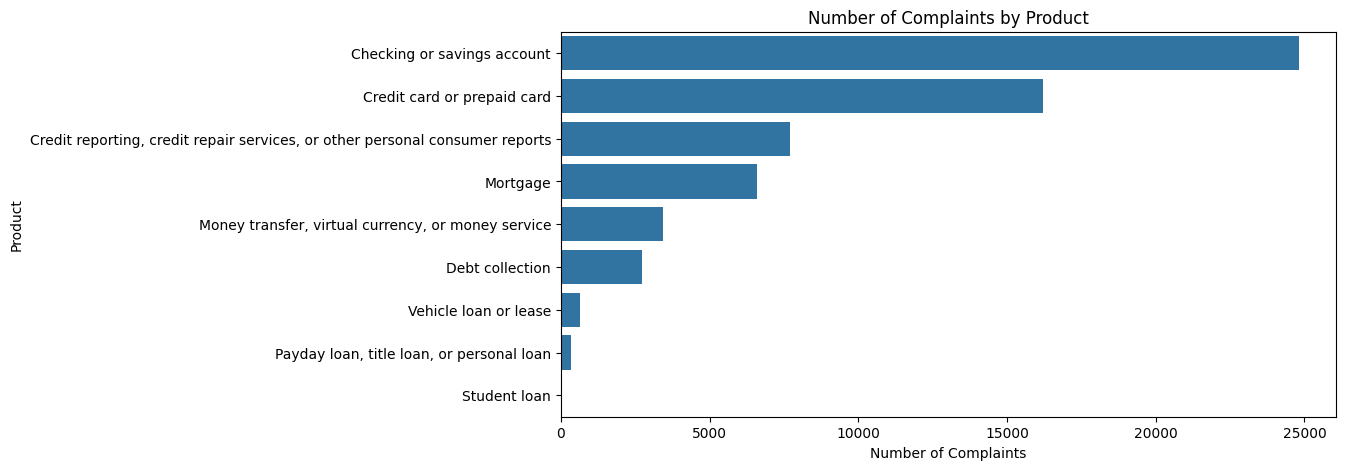

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count complaints by product
product_counts = df['Product'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=product_counts.values, y=product_counts.index)

plt.title("Number of Complaints by Product")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

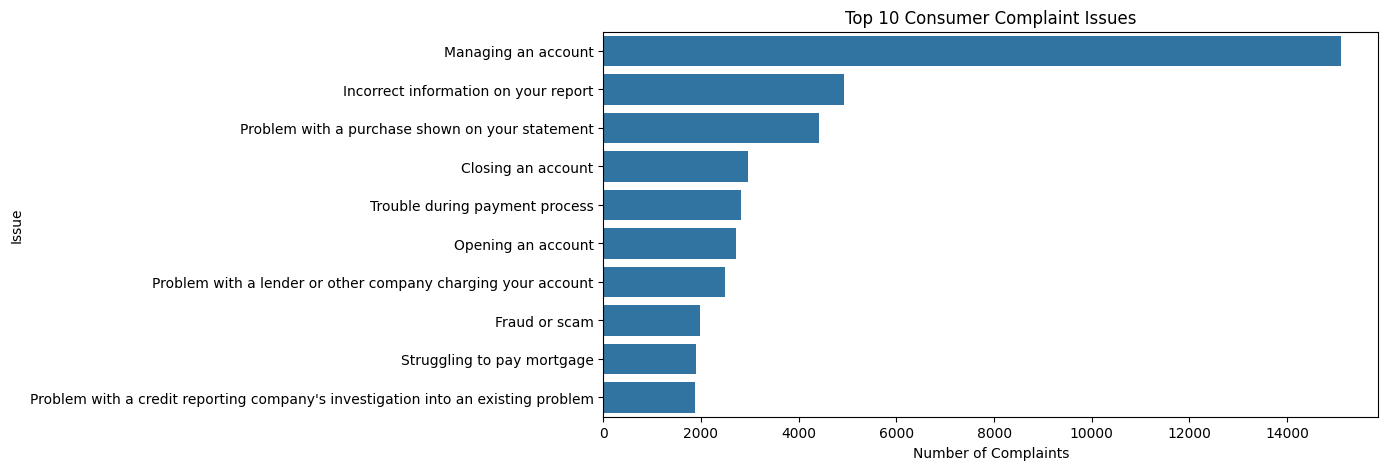

In [36]:
# Count complaints by issue
issue_counts = df['Issue'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=issue_counts.values, y=issue_counts.index)

plt.title("Top 10 Consumer Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()

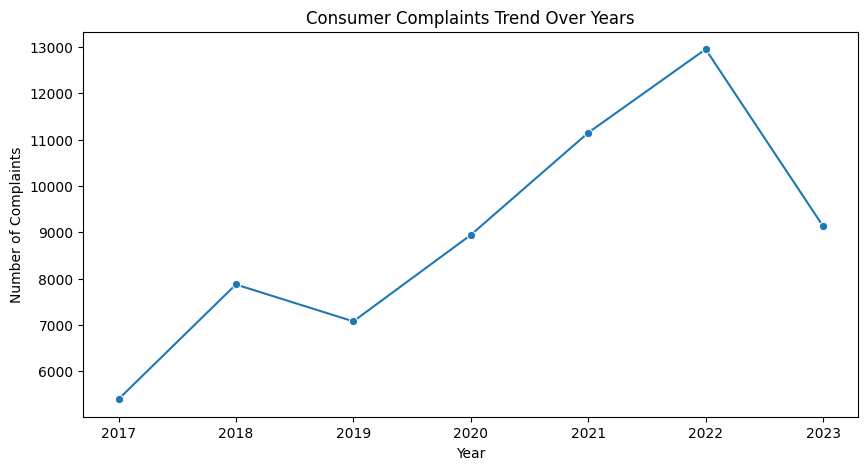

In [37]:
# Count complaints by year
year_counts = df['Complaint Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')

plt.title("Consumer Complaints Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")

plt.show()

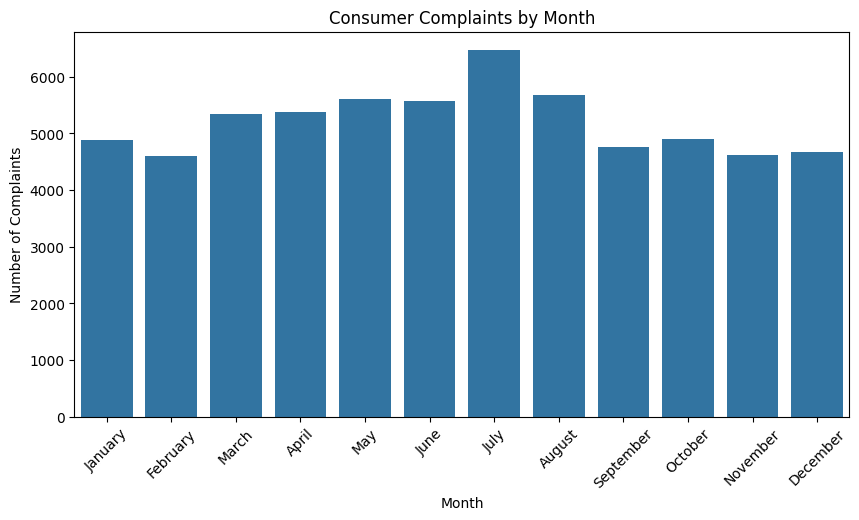

In [38]:
# Count complaints by month
month_counts = df['Complaint Month'].value_counts()

# Arrange months in calendar order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_counts = month_counts.reindex(month_order)

plt.figure(figsize=(10,5))
sns.barplot(x=month_counts.index, y=month_counts.values)

plt.title("Consumer Complaints by Month")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.show()

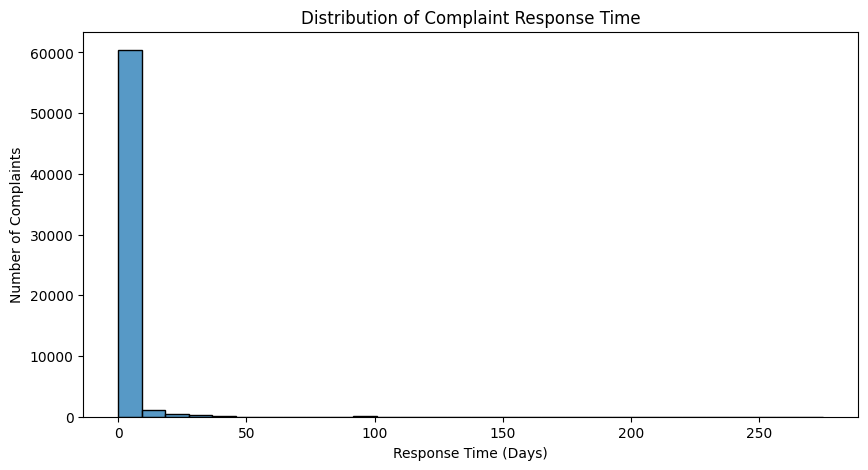

In [39]:
# Distribution of response time

plt.figure(figsize=(10,5))

sns.histplot(df['Response Time (Days)'], bins=30)

plt.title("Distribution of Complaint Response Time")
plt.xlabel("Response Time (Days)")
plt.ylabel("Number of Complaints")

plt.show()

In [40]:
# Top 10 longest response times

df[['Response Time (Days)', 'Product', 'Issue']].sort_values(
    by='Response Time (Days)',
    ascending=False
).head(10)

,Response Time (Days),Product,Issue
18384,275,Debt collection,Attempts to collect debt not owed
52724,181,Credit card or prepaid card,Problem when making payments
49646,179,Mortgage,Applying for a mortgage or refinancing an exis...
57264,161,Credit card or prepaid card,Problem with a purchase or transfer
35899,153,Mortgage,Struggling to pay mortgage
49363,130,Checking or savings account,Problem with a lender or other company chargin...
29915,129,Debt collection,Attempts to collect debt not owed
9732,128,Mortgage,Trouble during payment process
50305,123,Debt collection,Attempts to collect debt not owed
38962,109,Credit card or prepaid card,Getting a credit card


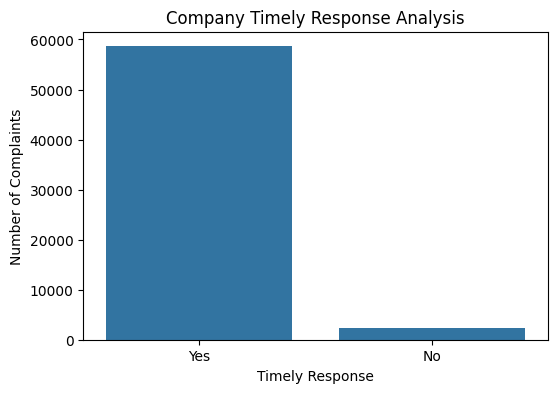

In [41]:
# Count timely response categories

timely_counts = df['Timely response?'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=timely_counts.index,
    y=timely_counts.values
)

plt.title("Company Timely Response Analysis")
plt.xlabel("Timely Response")
plt.ylabel("Number of Complaints")

plt.show()

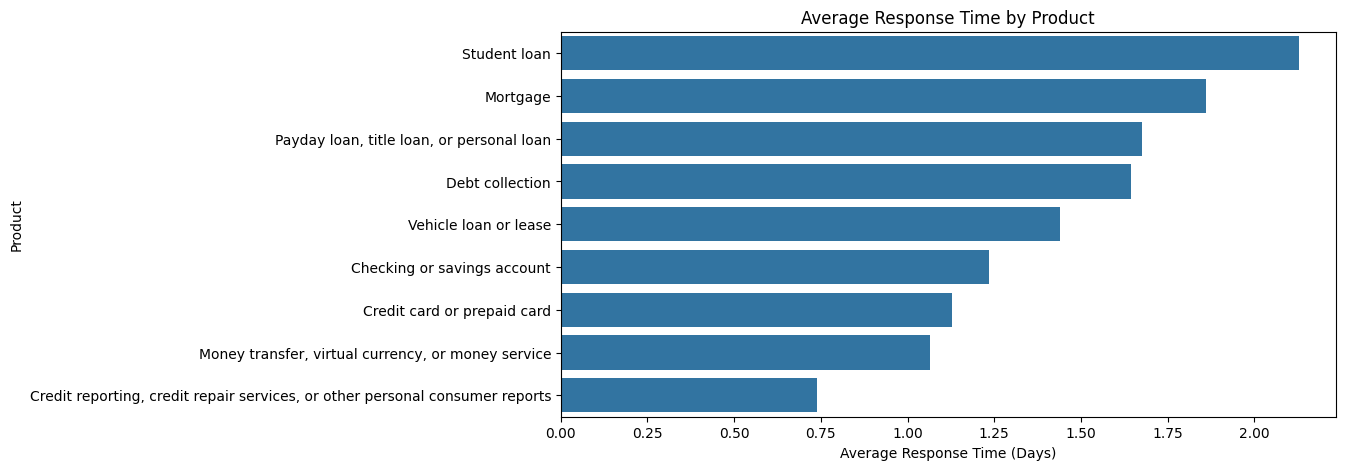

In [42]:
# Average response time by product

product_response = df.groupby('Product')['Response Time (Days)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=product_response.values,
    y=product_response.index
)

plt.title("Average Response Time by Product")
plt.xlabel("Average Response Time (Days)")
plt.ylabel("Product")

plt.show()

In [43]:
# Count number of complaints for each product

product_complaints = df['Product'].value_counts()

# Show top 10 products

product_complaints.head(10)

,count
Product,
Checking or savings account,24814
Credit card or prepaid card,16197
"Credit reporting, credit repair services, or other personal consumer reports",7710
Mortgage,6601
"Money transfer, virtual currency, or money service",3453
Debt collection,2736
Vehicle loan or lease,633
"Payday loan, title loan, or personal loan",333
Student loan,39


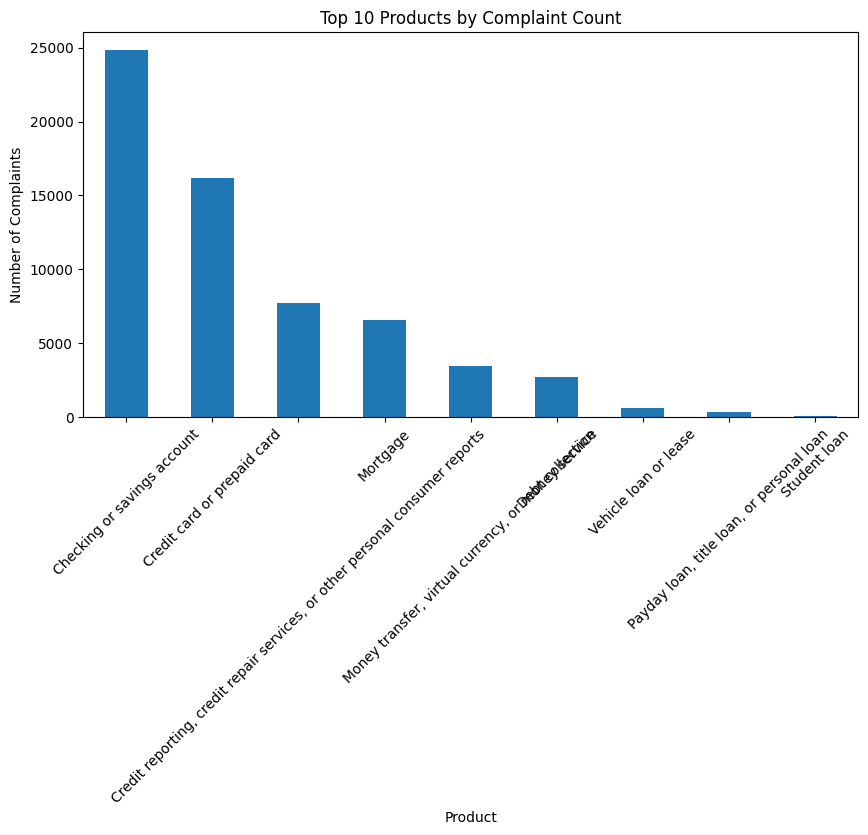

In [44]:
# Create a bar chart

plt.figure(figsize=(10,5))

product_complaints.head(10).plot(kind='bar')

plt.title("Top 10 Products by Complaint Count")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

In [45]:
# Count complaints by issue

issue_count = df['Issue'].value_counts()

# Show top 10 issues

issue_count.head(10)

,count
Issue,
Managing an account,15109
Incorrect information on your report,4931
Problem with a purchase shown on your statement,4415
Closing an account,2953
Trouble during payment process,2827
Opening an account,2725
Problem with a lender or other company charging your account,2493
Fraud or scam,1987
Struggling to pay mortgage,1904


In [46]:
# Filter only checking account complaints

checking_account = df[df['Product'] == 'Checking or savings account']

# Count issues

checking_issues = checking_account['Issue'].value_counts()

# Show top 10 issues

checking_issues.head(10)

,count
Issue,
Managing an account,15109
Closing an account,2953
Opening an account,2725
Problem with a lender or other company charging your account,2493
Problem caused by your funds being low,1330
Incorrect information on your report,129
Problem with a credit reporting company's investigation into an existing problem,20
Problem with fraud alerts or security freezes,17
Credit monitoring or identity theft protection services,17


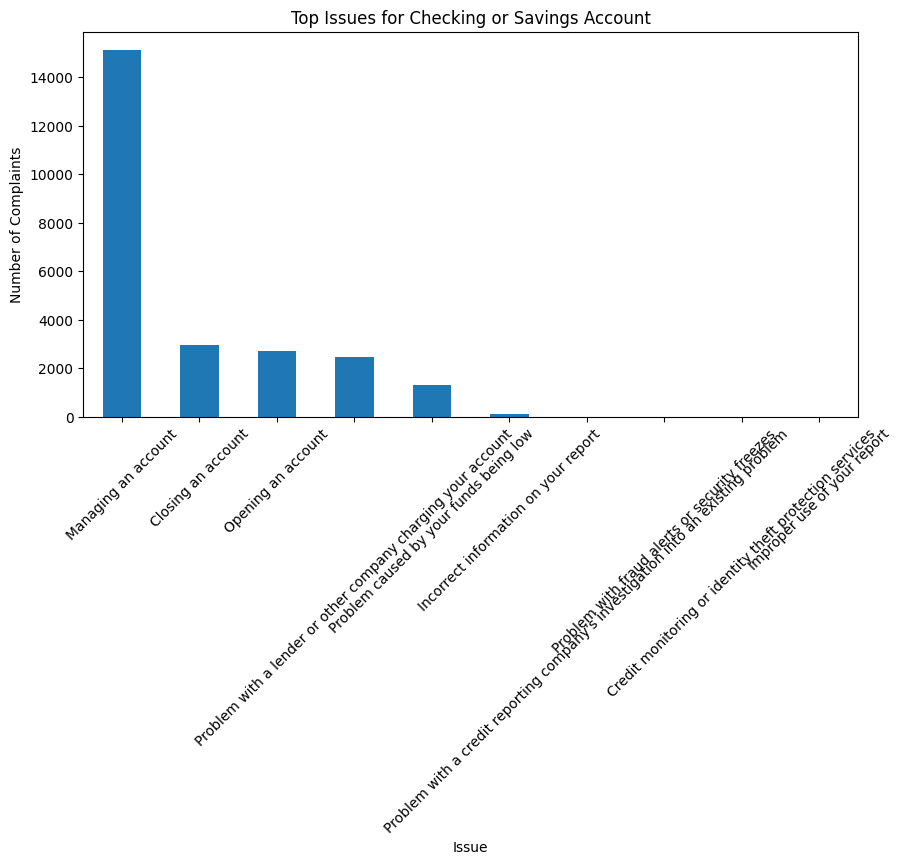

In [47]:
# Plot top issues for checking accounts

checking_issues.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Issues for Checking or Savings Account")
plt.xlabel("Issue")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.show()

In [48]:
# Count company responses

response_count = df['Company response to consumer'].value_counts()

# Show results

response_count

,count
Company response to consumer,
Closed with explanation,41044
Closed with monetary relief,14697
Closed with non-monetary relief,5273
In progress,1494
Closed,8


In [52]:
df[["Product","Issue","Response Time (Days)","Timely response?","Priority Score"]].head(10)

,Product,Issue,Response Time (Days),Timely response?,Priority Score
0,Mortgage,Applying for a mortgage or refinancing an exis...,3,Yes,0
1,"Money transfer, virtual currency, or money ser...",Lost or stolen check,0,Yes,5
2,"Credit reporting, credit repair services, or o...",Incorrect information on your report,0,Yes,35
3,Credit card or prepaid card,Problem getting a card or closing an account,1,NaN,15
4,Credit card or prepaid card,Closing your account,1,Yes,15
5,Credit card or prepaid card,Getting a credit card,0,Yes,20
6,Checking or savings account,Closing an account,0,Yes,35
7,"Credit reporting, credit repair services, or o...",Incorrect information on your report,0,Yes,35
8,Credit card or prepaid card,Fees or interest,0,Yes,20
9,Checking or savings account,Closing an account,0,Yes,35


In [53]:
# Create Priority Level

df["Priority Level"] = "Low"

df.loc[df["Priority Score"] >= 30, "Priority Level"] = "Medium"
df.loc[df["Priority Score"] >= 50, "Priority Level"] = "High"

In [54]:
df["Priority Level"].value_counts()

,count
Priority Level,
Low,33050
Medium,26324
High,3142


In [55]:
df.to_csv("Consumer_Complaints_Cleaned.csv", index=False)

In [56]:
pivot = df.pivot_table(
    index="Product",
    columns="Complaint Year",
    values="Complaint ID",
    aggfunc="count",
    fill_value=0
)

In [57]:
pivot

Complaint Year,2017,2018,2019,2020,2021,2022,2023
Product,,,,,,,
Checking or savings account,2039,3176,3080,3242,4006,5186,4085
Credit card or prepaid card,1125,1804,1789,2552,3084,3445,2398
"Credit reporting, credit repair services, or other personal consumer reports",466,761,627,1044,1642,1858,1312
Debt collection,287,415,305,353,671,462,243
"Money transfer, virtual currency, or money service",141,306,333,432,599,1035,607
Mortgage,1248,1294,830,1143,953,774,359
"Payday loan, title loan, or personal loan",34,40,31,65,76,63,24
Student loan,8,11,4,6,5,3,2
Vehicle loan or lease,46,65,76,105,113,127,101


In [58]:
import sqlite3

conn = sqlite3.connect("complaints.db")
df.to_sql("complaints", conn, if_exists="replace", index=False)

62516

In [59]:
df.head()

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Response Time (Days),Complaint Year,Complaint Month,Complaint Quarter,Priority Score,Priority Level
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Not Specified,Company has responded to the consumer and the ...,Closed with explanation,Yes,3,2021,October,4,0,Low
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money ser...",Refund anticipation check,Lost or stolen check,Not Specified,Company has responded to the consumer and the ...,Closed with monetary relief,Yes,0,2020,April,2,5,Low
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,Closed with explanation,Yes,0,2022,July,3,35,Medium
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a ...",No Public Response,In progress,NaN,1,2023,July,3,15,Low
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the ...,Closed with explanation,Yes,1,2022,July,3,15,Low


In [60]:
query = """
SELECT Product, Issue, "Response Time (Days)"
FROM complaints
WHERE "Timely response?" = 'No'
ORDER BY "Response Time (Days)" DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,Product,Issue,Response Time (Days)
0,Checking or savings account,Managing an account,103
1,Credit card or prepaid card,Problem with a purchase shown on your statement,90
2,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,54
3,Checking or savings account,Managing an account,40
4,Checking or savings account,Problem with a lender or other company chargin...,37
5,"Credit reporting, credit repair services, or o...",Improper use of your report,36
6,"Credit reporting, credit repair services, or o...",Improper use of your report,36
7,Vehicle loan or lease,Struggling to pay your loan,33
8,Checking or savings account,Managing an account,32
9,"Credit reporting, credit repair services, or o...",Incorrect information on your report,32


In [61]:
query = """
SELECT Product, COUNT(*) AS complaint_count
FROM complaints
GROUP BY Product
ORDER BY complaint_count DESC;
"""
result = pd.read_sql(query, conn)
result

,Product,complaint_count
0,Checking or savings account,24814
1,Credit card or prepaid card,16197
2,"Credit reporting, credit repair services, or o...",7710
3,Mortgage,6601
4,"Money transfer, virtual currency, or money ser...",3453
5,Debt collection,2736
6,Vehicle loan or lease,633
7,"Payday loan, title loan, or personal loan",333
8,Student loan,39


In [62]:
query = """
SELECT "Complaint Month", COUNT(*) AS complaint_count
FROM complaints
GROUP BY "Complaint Month"
ORDER BY complaint_count DESC;
"""
result = pd.read_sql(query, conn)
result

,Complaint Month,complaint_count
0,July,6474
1,August,5684
2,May,5608
3,June,5575
4,April,5386
5,March,5335
6,October,4902
7,January,4883
8,September,4765
9,December,4676


KPI:

In [63]:
query = """
SELECT "Company response to consumer", COUNT(*) AS total
FROM complaints
GROUP BY "Company response to consumer";
"""
result = pd.read_sql(query, conn)
result

,Company response to consumer,total
0,Closed,8
1,Closed with explanation,41044
2,Closed with monetary relief,14697
3,Closed with non-monetary relief,5273
4,In progress,1494


In [64]:
query = """
SELECT
  ROUND(100.0 * SUM(CASE WHEN "Timely response?" = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_timely
FROM complaints;
"""
result = pd.read_sql(query, conn)
result

,pct_timely
0,93.77


In [65]:
query = """
SELECT Product, ROUND(AVG("Response Time (Days)"), 2) AS avg_response_days
FROM complaints
GROUP BY Product
ORDER BY avg_response_days DESC;
"""
result = pd.read_sql(query, conn)
result

,Product,avg_response_days
0,Student loan,2.13
1,Mortgage,1.86
2,"Payday loan, title loan, or personal loan",1.68
3,Debt collection,1.64
4,Vehicle loan or lease,1.44
5,Checking or savings account,1.23
6,Credit card or prepaid card,1.13
7,"Money transfer, virtual currency, or money ser...",1.06
8,"Credit reporting, credit repair services, or o...",0.74


In [66]:
query = """
SELECT "Complaint Year", COUNT(*) AS total_complaints
FROM complaints
GROUP BY "Complaint Year"
ORDER BY "Complaint Year";
"""
result = pd.read_sql(query, conn)
result

,Complaint Year,total_complaints
0,2017,5394
1,2018,7872
2,2019,7075
3,2020,8942
4,2021,11149
5,2022,12953
6,2023,9131
